<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


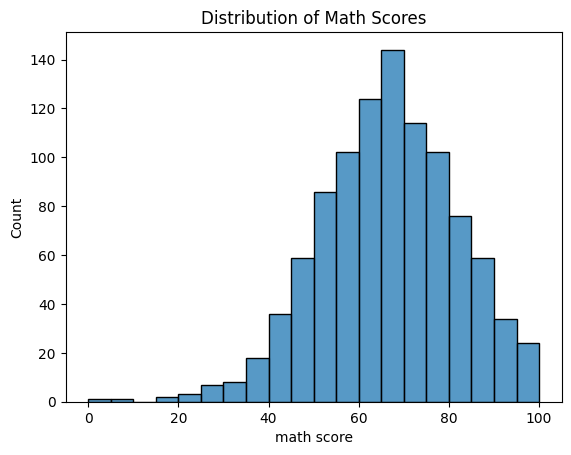

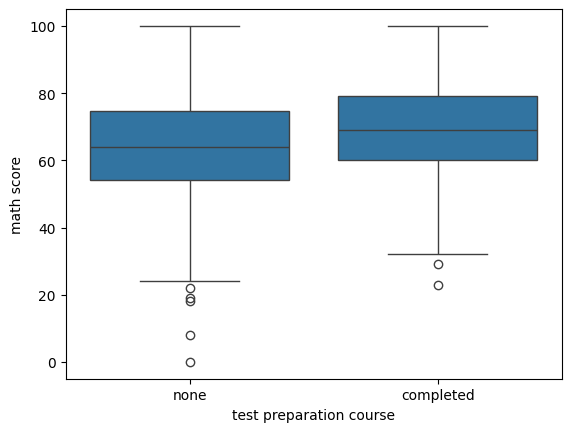

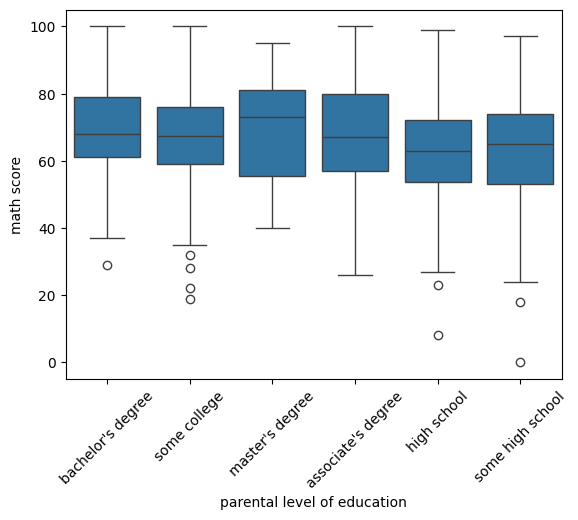

MAE: 4.72855


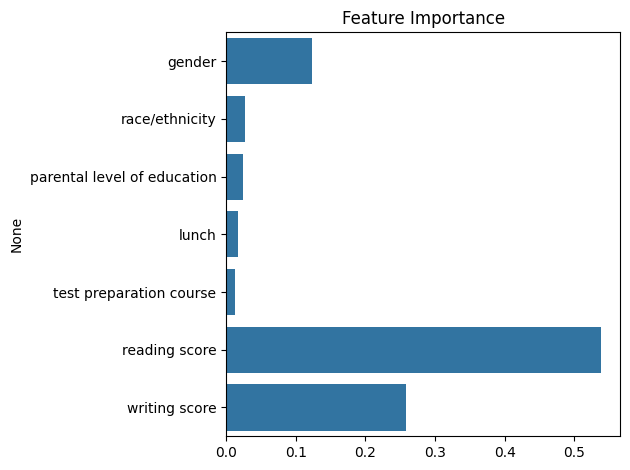

Conclusion:
- Students who completed the test preparation course scored on average higher.
- Reading score strongly correlates with writing score.
- Parental education level correlates with performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

df = pd.read_csv("../data/StudentsPerformance.csv")
df.head()
df.info()
df.describe()

# Exploratory Data Analysis
sns.histplot(df["math score"], bins=20)
plt.title("Distribution of Math Scores")
plt.show()

sns.boxplot(x="test preparation course", y="math score", data=df)
plt.show()

sns.boxplot(x="parental level of education", y="math score", data=df)
plt.xticks(rotation=45)
plt.show()

# Encoding the full dataframe 
label_encoders = {}
for col in df.columns:
    if df[col].dtype == "object" or pd.api.types.is_string_dtype(df[col]):
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Splitting into features and target 
X = df.drop("math score", axis=1)
y = df["math score"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modeling
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Evaluation
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

# Feature Importance Plot
importance = model.feature_importances_
sns.barplot(x=importance, y=X.columns)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# Conclusion
conclusion = (
    "Conclusion:\n"
    "- Students who completed the test preparation course scored on average higher.\n"
    "- Reading score strongly correlates with writing score.\n"
    "- Parental education level correlates with performance."
)
print(conclusion)